# Products, Pricing and Volatility: Home Assignment 1


**Part 1. Derivative Pricing models.**

Task 1.

In the Vasicek model, the short rate $r_t$ follows the risk‑neutral dynamics  

$
dr_t = a(b - r_t)\,dt + \sigma \, dW_t,
$

where $a$ is the speed of mean reversion, $b$ the long‑term mean rate, and $\sigma$ the volatility.  
The price at time $t$ of a zero‑coupon bond paying 1 at maturity $T$ is  

$
P(t,T) = \mathbb{E}_t\!\left[ \exp\!\left( -\int_t^T r_s \,ds \right) \right].
$

The model is affine:

$
P(t,T) = \exp\!\bigl( A(t,T) - B(t,T)\, r_t \bigr),
$

with deterministic functions $A(t,T)$ and $B(t,T)$.

$
\frac{\partial B}{\partial t} + a B - 1 = 0, \qquad
\frac{\partial A}{\partial t} - a b B + \frac{1}{2}\sigma^2 B^2 = 0,
$

subject to $A(T,T)=0,\; B(T,T)=0$.



$
B(t,T) = \frac{1 - e^{-a(T-t)}}{a}.
$


$
A(t,T) = \int_t^T \left( a b B(s,T) - \frac{1}{2}\sigma^2 B(s,T)^2 \right) ds.
$



$
A(t,T) = \frac{\bigl(B(t,T) - (T-t)\bigr)\bigl(a^2 b - \frac{\sigma^2}{2}\bigr)}{a^2} - \frac{\sigma^2 B(t,T)^2}{4a}.
$

Thus the bond price is  

$
P(t,T) = \exp\!\left( \frac{\bigl(B(t,T) - (T-t)\bigr)\bigl(a^2 b - \frac{\sigma^2}{2}\bigr)}{a^2} - \frac{\sigma^2 B(t,T)^2}{4a} - B(t,T) r_t \right).
$

Now plug in the given numbers:  
$a = 0.1$, $b = 0.05$, $\sigma = 0.02$, $r_t = 0.03$, $t = 0$, $T = 1$.

$
P(0,1) = \exp\!\left( -B r_0 + (B-1)\left(b - \frac{\sigma^2}{2a^2}\right) - \frac{\sigma^2 B^2}{4a} \right),
$  

where  
$ a = 0.1 $, $ b = 0.05 $, $ \sigma = 0.02 $, $ r_0 = 0.03 $, and  
$ B = \frac{1 - e^{-a}}{a} = \frac{1 - e^{-0.1}}{0.1} \approx 0.9516 $.  

Substituting the values:  
$
b - \frac{\sigma^2}{2a^2} = 0.05 - \frac{0.0004}{2 \times 0.01} = 0.03,
$  
$
(B-1) = -0.0484, \quad (B-1)\times 0.03 = -0.0015,
$  
$
\frac{\sigma^2 B^2}{4a}  = 0.0009,
$  
$
-B r_0 = -0.9516 \times 0.03 = -0.0285.
$  

$
P(0,1) = e^{-0.0285 - 0.0015 - 0.0009} \approx 0.9696.
$

Thus the price of the one-year zero-coupon bond is **0.9696** per unit face value.



Task 2.

In [ ]:
import numpy as np
from scipy.optimize import minimize

maturities = np.array([1, 2, 3, 5, 10])
market_prices = np.array([0.98, 0.95, 0.93, 0.90, 0.75])

b = 0.03
sigma = 0.02
r0 = 0.02

def vasicek_price(a, T):
    """Vasicek zero-coupon bond price for maturity T, given speed a."""
    if a <= 0:
        return np.nan
    B = (1 - np.exp(-a * T)) / a
    A = ((B - T) * (a**2 * b - 0.5 * sigma**2)) / a**2 - (sigma**2 * B**2) / (4 * a)
    return np.exp(A - B * r0)

def rmse(a):
    """Compute RMSE between theoretical and market prices."""
    theo = np.array([vasicek_price(a, T) for T in maturities])
    return np.sqrt(np.mean((theo - market_prices)**2))


a0 = 0.1
# Bounds: a > 0
bounds = [(1e-6, None)]
result = minimize(rmse, a0, bounds=bounds, method='L-BFGS-B')

a_opt = result.x[0]
rmse_opt = result.fun

# Compute fitted prices
fitted_prices = [vasicek_price(a_opt, T) for T in maturities]

print(f"Calibrated speed of reversion a = {a_opt:.6f}")
print(f"RMSE = {rmse_opt:.6f}")
print("\nMaturity  Market Price  Fitted Price")
for T, mkt, fit in zip(maturities, market_prices, fitted_prices):
    print(f"{T:2d} year      {mkt:.4f}         {fit:.4f}")

Calibrated speed of reversion a = 0.000003
RMSE = 0.094257

Maturity  Market Price  Fitted Price
 1 year      0.9800         0.9801
 2 year      0.9500         0.9612
 3 year      0.9300         0.9434
 5 year      0.9000         0.9122
10 year      0.7500         0.8752


**Part 2. Greeks & Delta Hedging**

Task 1.
The Delta of a European call option in the Black–Scholes model is the partial derivative of the option price with respect to the underlying asset price $S$. Starting from the Black–Scholes formula:

$
C = S \, N(d_1) - K e^{-rT} N(d_2),
$

where  
$
d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma \sqrt{T}}, \quad d_2 = d_1 - \sigma \sqrt{T}.
$

$
\Delta = \frac{\partial C}{\partial S} = N(d_1) + S \frac{\partial N(d_1)}{\partial S} - K e^{-rT} \frac{\partial N(d_2)}{\partial S}.
$

Chain rule, $\frac{\partial N(d_i)}{\partial S} = n(d_i) \frac{\partial d_i}{\partial S}$.
$
\frac{\partial d_1}{\partial S} = \frac{1}{S \sigma \sqrt{T}}, \quad \frac{\partial d_2}{\partial S} = \frac{\partial d_1}{\partial S} = \frac{1}{S \sigma \sqrt{T}}.
$

Substitute:

$
\Delta = N(d_1) + S \, n(d_1) \frac{1}{S \sigma \sqrt{T}} - K e^{-rT} n(d_2) \frac{1}{S \sigma \sqrt{T}} = N(d_1) + \frac{n(d_1)}{\sigma \sqrt{T}} - \frac{K e^{-rT} n(d_2)}{S \sigma \sqrt{T}}
$


 $S n(d_1) = K e^{-rT} n(d_2)$

 Then:

$
\frac{K e^{-rT} n(d_2)}{S \sigma \sqrt{T}} = \frac{n(d_1)}{\sigma \sqrt{T}}.
$

Thus:

$
\Delta = N(d_1).
$



Task 2

(a) Delta = 0.281548
(b) Long 28.15 shares
(c) P&L per option at S=$39: -0.018225
    Total for 100 shares: $-1.82
(d) P&L per option at S=$40.50: 0.004905
    Total for 100 shares: $0.49


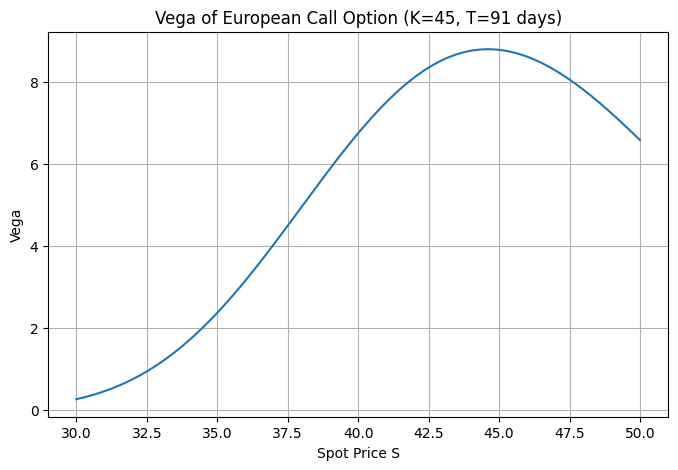

In [ ]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# Parameters
S0 = 40.0
K = 45.0
sigma = 0.3
r = 0.08
T = 91 / 365.0          # time to expiration in years
dt = 1 / 365.0          # one day

def bs_call(S, K, T, r, sigma):
    """Black–Scholes European call price and d1, d2."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call, d1, d2

# (a) Delta of the option
C0, d1_0, _ = bs_call(S0, K, T, r, sigma)
delta0 = norm.cdf(d1_0)
print(f"(a) Delta = {delta0:.6f}")

# (b) Shares to hedge a position on 100 shares
shares = delta0 * 100
print(f"(b) Long {shares:.2f} shares")

# (c) Overnight P&L when stock goes to $39
S1 = 39.0
T1 = T - dt
C1, _, _ = bs_call(S1, K, T1, r, sigma)
cash0 = C0 - delta0 * S0          # initial cash (negative means borrowed)
cash1 = cash0 * np.exp(r * dt)    # cash after one day with interest
pnl1 = -C1 + delta0 * S1 + cash1
print(f"(c) P&L per option at S=$39: {pnl1:.6f}")
print(f"    Total for 100 shares: ${pnl1*100:.2f}")

# (d) Overnight P&L when stock goes to $40.50
S2 = 40.5
C2, _, _ = bs_call(S2, K, T1, r, sigma)
pnl2 = -C2 + delta0 * S2 + cash1
print(f"(d) P&L per option at S=$40.50: {pnl2:.6f}")
print(f"    Total for 100 shares: ${pnl2*100:.2f}")

# (e) Vega for different spot prices
S_range = np.linspace(30, 50, 200)
vega = []
for S in S_range:
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    vega_val = S * norm.pdf(d1) * np.sqrt(T)
    vega.append(vega_val)

plt.figure(figsize=(8, 5))
plt.plot(S_range, vega)
plt.xlabel('Spot Price S')
plt.ylabel('Vega')
plt.title('Vega of European Call Option (K=45, T=91 days)')
plt.grid(True)
plt.show()

Task 3

In [ ]:
import numpy as np
from scipy.stats import norm

# Parameters
S0 = 40.0
K = 40.0
sigma = 0.3
r = 0.08
T = 180 / 360.0
dt = 1 / 360.0

# Black–Scholes formulas
d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

delta = norm.cdf(d1)
gamma = norm.pdf(d1) / (S0 * sigma * np.sqrt(T))
theta = - (S0 * sigma * norm.pdf(d1)) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
C0 = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

print(f"d1 = {d1:.6f}, d2 = {d2:.6f}")
print(f"Delta = {delta:.6f}")
print(f"Gamma = {gamma:.6f}")
print(f"Theta (per year) = {theta:.6f}")
print(f"Initial call price = {C0:.6f}")

# (a) Stock price decreases to $36 after 1 day
S1 = 36.0
dS = S1 - S0
delta_C_approx = delta * dS + 0.5 * gamma * dS**2 + theta * dt
C1_approx = C0 + delta_C_approx
print(f"\n(a) Approximated option value after 1 day at S=$36: {C1_approx:.6f}")

# (b) Break‑even market move for a delta‑hedged short call
dS_sq = -2 * theta * dt / gamma   # because theta is negative
dS_breakeven = np.sqrt(dS_sq)
print(f"(b) Break‑even market move magnitude: ±{dS_breakeven:.6f} (i.e., stock price change of ±{dS_breakeven:.4f})")

d1 = 0.294628, d2 = 0.082496
Delta = 0.615861
Gamma = 0.045019
Theta (per year) = -4.879690
Initial call price = 4.155256

(a) Approximated option value after 1 day at S=$36: 2.038409
(b) Break‑even market move magnitude: ±0.776002 (i.e., stock price change of ±0.7760)


**Part 3. Volatility**


Task 1

In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import root_scalar

S = 100.0
r = 0.05
T = 1.0

def bs_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def implied_vol(K, target):
    def f(sigma):
        return bs_call(S, K, T, r, sigma) - target
    try:
        sol = root_scalar(f, bracket=[0.01, 1.0], method='brentq')
        return sol.root
    except:
        return np.nan

iv_110 = implied_vol(110, 6.040)
iv_130 = implied_vol(130, 4.673)

print(f"Implied vol at 110: {iv_110*100:.2f}%")
print(f"Implied vol at 130: {iv_130*100:.2f}%")

# Linear interpolation for strike 120
iv_120 = iv_110 + (iv_130 - iv_110) * (120-110)/(130-110)
print(f"Interpolated vol at 120: {iv_120*100:.2f}%")

# Price at 120
call_120 = bs_call(S, 120, T, r, iv_120)
print(f"Call price at strike 120: {call_120:.4f}")

Implied vol at 110: 20.00%
Implied vol at 130: 30.00%
Interpolated vol at 120: 25.00%
Call price at strike 120: 5.0252


Task 2.

Given: ATM = 15%, RR25d = -2%, FLY25d = 1%.  

From definitions:  
$
\sigma_{25C} - \sigma_{25P} = -0.02
$  
$
\frac{\sigma_{25C} + \sigma_{25P}}{2} - 0.15 = 0.01 \quad\Rightarrow\quad \sigma_{25C}+\sigma_{25P}=0.32
$  
 $\sigma_{25C}=0.15$, $\sigma_{25P}=0.17$   


$
\sigma_{30P} = 17\% - \frac{17\%-15\%}{0.5-0.25}\times(0.3-0.25) = 17\% - 2\%\times\frac{0.05}{0.25} = 17\% - 0.4\% = 16.6\%.
$

